<a href="https://colab.research.google.com/github/AyubUmair/ComputerVision/blob/main/EN3160.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
<center><h1><b>EN 3160 A01</h1></center>




##**Name:** Ayubkhan Umair

##**Index No:**  230654M

[GitHub Link](https://github.com/AyubUmair/ComputerVision)

In [21]:
! pip install opencv-python
import warnings; warnings.filterwarnings('ignore')

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Below function is used to show the outputs
def show(imgs, titles, cmap=None, figsize=(12,4)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1:
      axes = [axes]
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(im, cmap=cmap)
        ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.show()

# **Question 1**

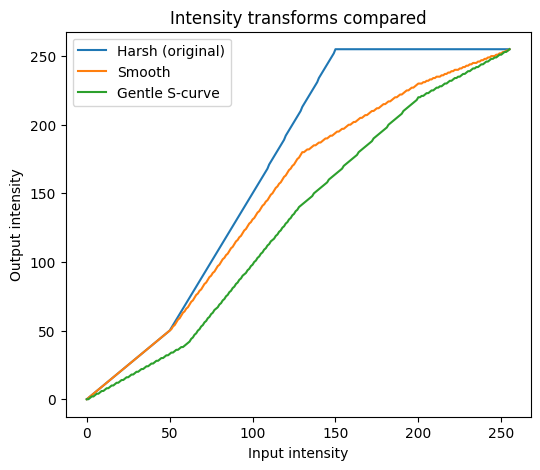

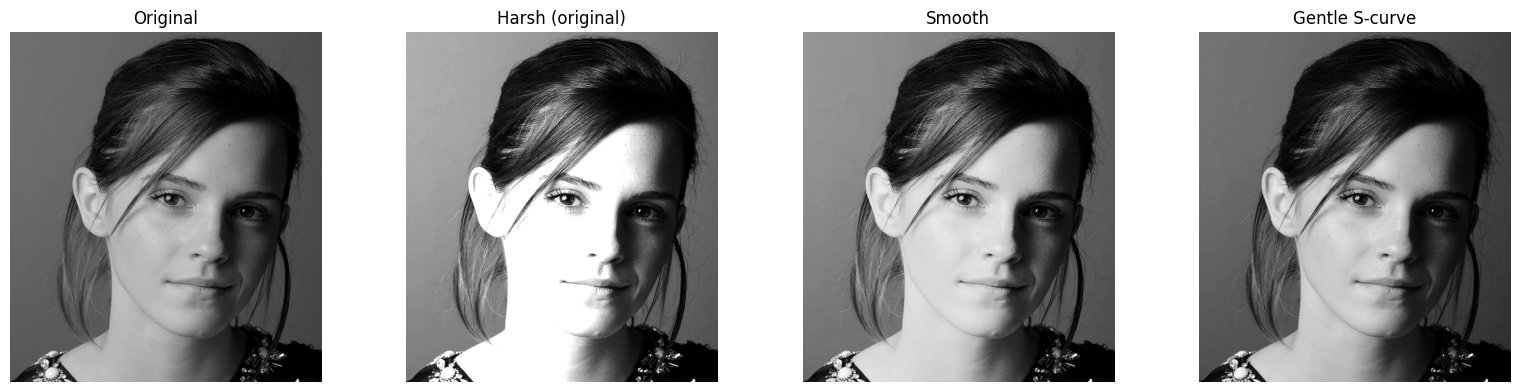

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints)
    x, y = breakpoints[:, 0], breakpoints[:, 1]
    lut = np.interp(np.arange(256), x, y).astype(np.uint8)
    return cv.LUT(im, lut), lut

image = cv.imread('fig 1.jpeg', cv.IMREAD_GRAYSCALE)
breakpoint_sets = {
    'Rough transform': [[0,0],   [50,50],  [100,150], [150,255], [255,255]],
    'Smooth':           [[0,0],   [50,50],  [130,180], [200,230], [255,255]],
    'Gentle curve':   [[0,0],   [60,40],  [128,140], [200,220], [255,255]],
}

outputs, luts = {}, {}
for name, bp in breakpoint_sets.items():
    out, lut = intensity_transform(image, bp)
    outputs[name], luts[name] = out, lut
plt.figure(figsize=(6, 5))
for name, lut in luts.items():
    plt.plot(lut, label=name)
plt.xlabel('Input intensity'); plt.ylabel('Output intensity')
plt.title('Intensity transforms compared')
plt.legend(); plt.show()

imgs = [image] + list(outputs.values())
titles = ['Original'] + list(outputs.keys())
show(imgs, titles, cmap='gray', figsize=(4*len(imgs), 4))

**Transformation Profile Analysis**

Rough Transform: The curve steepens significantly between inputs 50 and 150. It reaches the top line when the input images intensity at 150. This forces any pixel originally brighter than 150 into pure white.

Smooth Transform: This curve steepens more slowly at the top, delaying the flatline until the input reaches 200. So,the brighter pixels get wider range of values to exist in before reaching pure white.

Gentle Curve: This curve bends downward slightly at the beginning (mapping input 60 to output 40) before smoothly curving upward. This stretches both the darkest shadows and the brightest highlights in a balanced way.

**Visual Comparison**

Rough Transform - Overexposure: The right side of the face is very bright in the transformed image. To see the natural 3D shape of a person's face in a photo, the shadows need to gradually fade into the light. This happened because the code took every part of the face that was even slightly bright and forced it to become pure white.

Smooth Transform: The face gets a nice, bright pop of light. Because the curve gives the bright pixels more range to exist. It allows to see the natural shape of the cheek and the texture of the skin.

Gentle Curve: This gives the most realistic look. The slight downward bend at the start makes the dark shadows deeper, while the smooth curve at the top brightens the skin naturally.

#**Question 2**

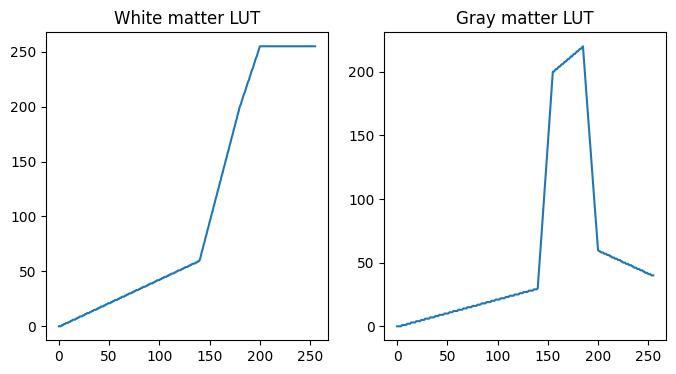

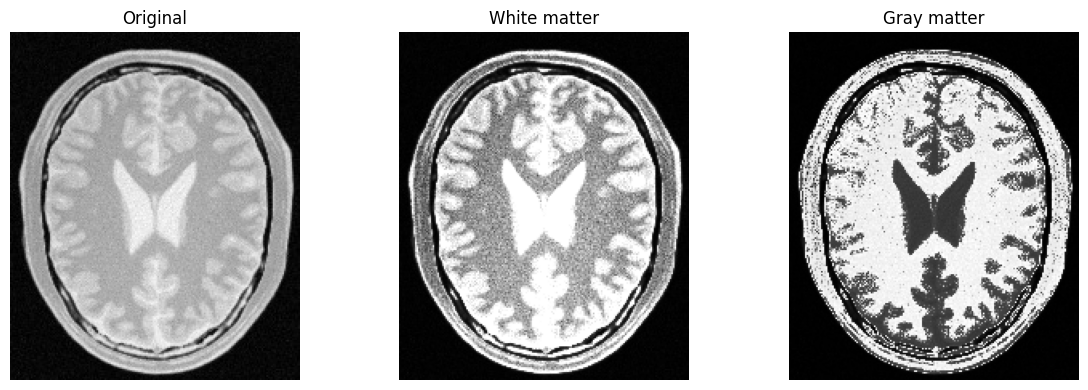

In [29]:
brain = cv.imread('fig 2.jpeg', cv.IMREAD_GRAYSCALE)
white_matter_bp = [[0,0], [140,60], [180,200], [200,255], [255,255]]
gray_matter_bp = [[0,0], [140,30], [155,200], [185,220], [200,60], [255,40]]
white_out, white_lut = intensity_transform(brain, white_matter_bp)
gray_out,  gray_lut  = intensity_transform(brain, gray_matter_bp)

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].plot(white_lut); ax[0].set_title('White matter LUT')
ax[1].plot(gray_lut);  ax[1].set_title('Gray matter LUT')
plt.show()

show([brain, white_out, gray_out], ['Original', 'White matter', 'Gray matter'], cmap='gray')

**White Matter**

*  Transformation: The breakpoints create a steep gradient in the higher intensity range. Here, I am mapping input values from 140 to 200 to output values of 60 to 255.

* Because the white matter regions belongs to these high intensity peaks, stretching this narrow input range across a wide output  increases their brightness and internal contrast.

* Lower input intensities (0–140), which represent the background and gray matter, are heavily compressed into a dark output range (0–60). So, the white matter is visible sharply.

**Gray Matter**



*   Transformation: For Gray matter isolation I am applying contrast stretch to the mid low intensity range, mapping a narrow 20-value input spread (90–110) across the range of 50–200.

*   So, the actual darker gray matter (the outer cortical rim) become intensely bright, separating it clearly from the dark background and skull boundary.

*   Trade off: Since the mapping curve remains high for all subsequent input values, both the gray and white matter are pushed toward the maximum white threshold. So, w can't see the internal structural boundaries within the brain tissue.









# **Question 3**

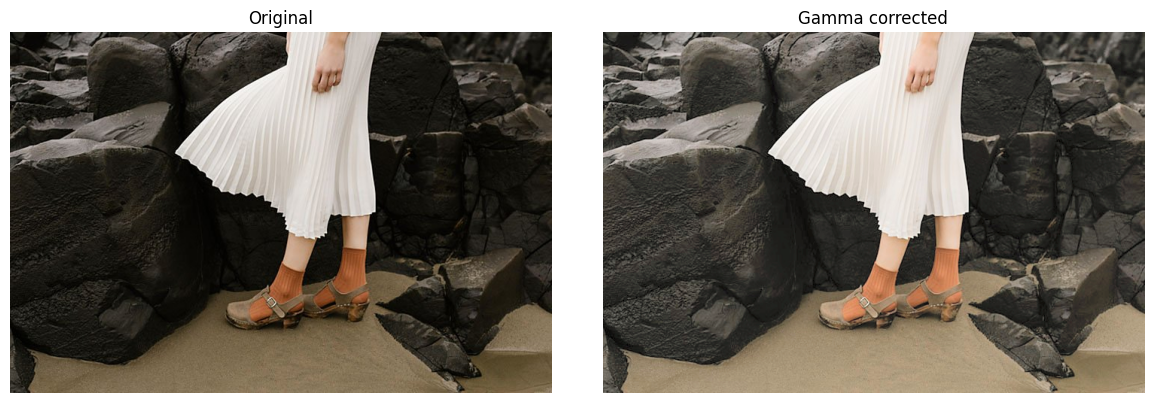

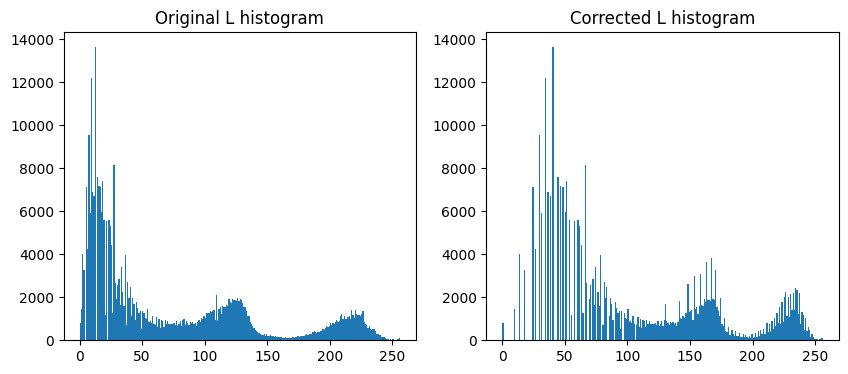

In [22]:
img = cv.imread('fig 3.jpeg')


lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.6
L_norm = L / 255.0
L_corrected = np.power(L_norm, gamma) * 255.0
L_corrected = L_corrected.astype(np.uint8)

lab_corrected = cv.merge([L_corrected, a, b])
img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

show([cv.cvtColor(img, cv.COLOR_BGR2RGB), cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB)],
     ['Original','Gamma corrected'])
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(L.ravel(), 256, [0,256]); ax[0].set_title('Original L histogram')
ax[1].hist(L_corrected.ravel(), 256, [0,256]); ax[1].set_title('Corrected L histogram')
plt.show()

**Visual Comparison**


* Background: In the original image, the rocks are highly underexposed, compressing the texture into black shadows. The gamma-corrected output successfully reveals the structural details, and tonal variations in the rock formations.

*  Subject: The subject's white skirt and the bright background remain well exposed. Because the gamma curve flattens at higher input values, these naturally bright regions are protected from severe overexposure.

**Histogram Analysis**


*   Original L Histogram: The data is heavily concentrated on the far left (intensities 0–50). It confirms  the underexposed nature of the rocks. A small, separate peak exists around 200–250, mapping to the white skirt.
*   Corrected L Histogram: The low-intensity spike has been stretched and pulled to the right, spreading the pixel values across a broader mid tone range. This redistribution of data is exactly what recovers the localized contrast in the dark regions. The high intensity peak also shifted slightly further right.






# **Question 4**

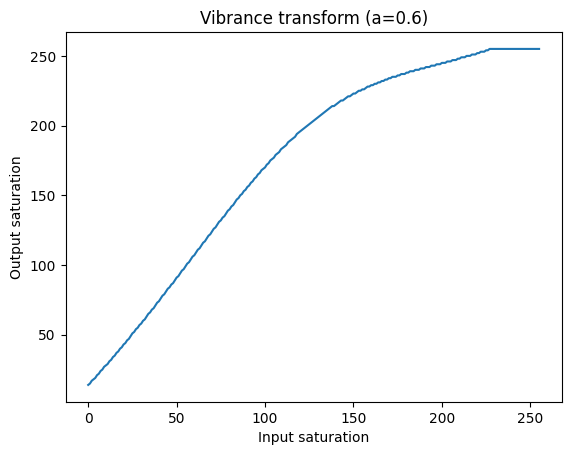

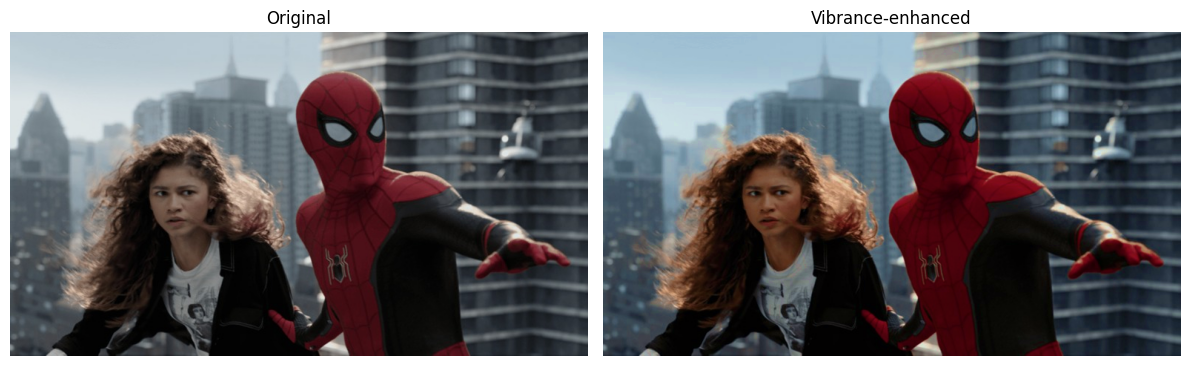

In [5]:
img = cv.imread('fig 4.jpeg')
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

def vibrance_lut(a, sigma=70):
    x = np.arange(256)
    f = x + a * 128 * np.exp(-((x-128)**2)/(2*sigma**2))
    return np.clip(f, 0, 255).astype(np.uint8)

a = 0.6
lut = vibrance_lut(a)
s_new = cv.LUT(s, lut)

hsv_new = cv.merge([h, s_new, v])
img_new = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

plt.plot(lut); plt.xlabel('Input saturation'); plt.ylabel('Output saturation')
plt.title(f'Vibrance transform (a={a})'); plt.show()
show([cv.cvtColor(img, cv.COLOR_BGR2RGB), cv.cvtColor(img_new, cv.COLOR_BGR2RGB)],
     ['Original','Vibrance-enhanced'])

**Transformation Curve Analysis**

*   Mid-Tone Amplification: The plotted curve shows that the maximum amplification occurs at the center of the input range, around saturation level 128. This curve targets pixels that are currently dull, providing them with the most significant grading.
*  The exponential decay of the Gaussian function ensures that the curve converges back toward a linear 1:1 mapping at the extreme levels (near 0 and 255). This prevents highly saturated pixels from clipping beyond the 255 maximum, and keeps neutral grays from get effected by artificial color noise.




**Visual Comparison**



*   Subjects: In the original image, the red fabric of the suit appears flat. The enhanced image displays a much vibranced, deeper red because the mid level saturation values of the suit were pushed upward by the peak of the transformation curve.
*   Skin Tones & Hair: Because this vibrance curve is non linear and controlled by the $a=0.6$ parameter, the warmth in the skin and the brown tones in the hair are enhanced naturally without appearing synthetic.

*   Background Preservation: The city skyline starts with very low saturation. According to the transformation plot, inputs near 0 receive near zero addition. So, the background remains somewhat similar and cool, which helps the foreground subjects stand out.









# **Question 5**

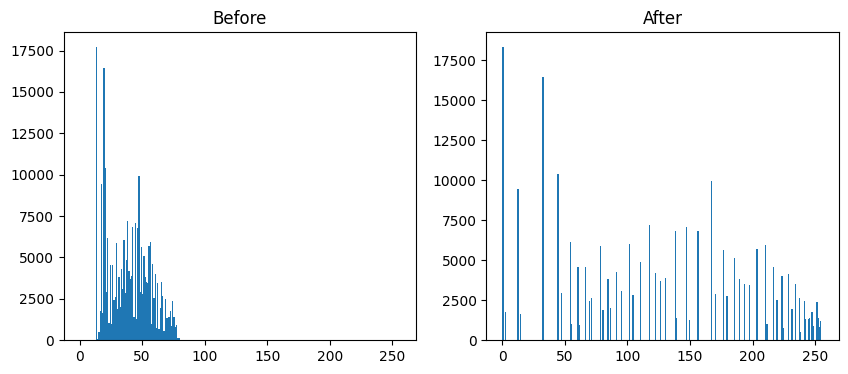

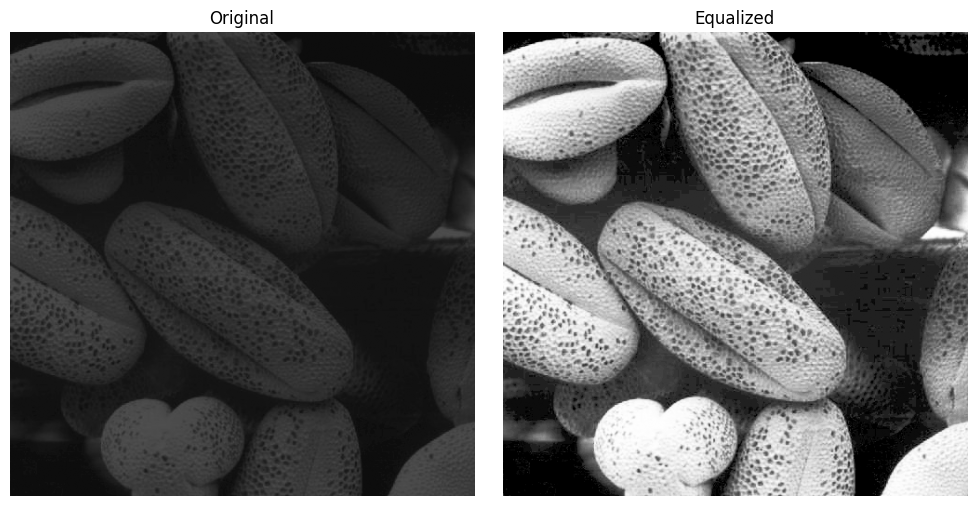

In [23]:
def hist_equalize(im):
    hist, _ = np.histogram(im.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_scaled = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    lut = np.ma.filled(cdf_scaled, 0).astype(np.uint8)
    return lut[im], lut

leaves = cv.imread('fig 5.tif', cv.IMREAD_GRAYSCALE)
eq, lut = hist_equalize(leaves)

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(leaves.ravel(), 256, [0,256]); ax[0].set_title('Before')
ax[1].hist(eq.ravel(), 256, [0,256]); ax[1].set_title('After')
plt.show()
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(leaves, cmap='gray', vmin=0, vmax=255)
axes2[0].set_title('Original')
axes2[0].axis('off')
axes2[1].imshow(eq, cmap='gray', vmin=0, vmax=255)
axes2[1].set_title('Equalized')
axes2[1].axis('off')
plt.tight_layout()
plt.show()

**Histogram Analysis**


*   Original Histogram: The input data is heavily skewed to the left, tightly grouped between intensity values of 0 and 100. This narrow spread mathematically confirms the heavy underexposure and low contrast visible in the original image.

*   Equalized Histogram: The transformation flattens and stretches the pixel distribution across the full 0–255 spectrum. The gaps between the bins in the "After" plot are a standard artifact of stretching discrete, quantized digital values. Because the algorithm cannot create new intermediate intensity values, so it pushes existing bins apart.

**Visual Impact**


*   Texture Recovery: The original image is too dark to clearly display surface features. By stretching the compressed dark values, the equalization process successfully shows the intricate micro features like ridges and pores on the surface of the image.
*    Because global histogram equalization applies the same transformation curve to the entire image, it streches everything. The naturally dark, uniform background is pushed into higher intensity ranges, resulting the visible gray noise and grain artifacts behind the primary subjects. This shows a key limitation of global equalization compared to localized methods.








# **Question 6**

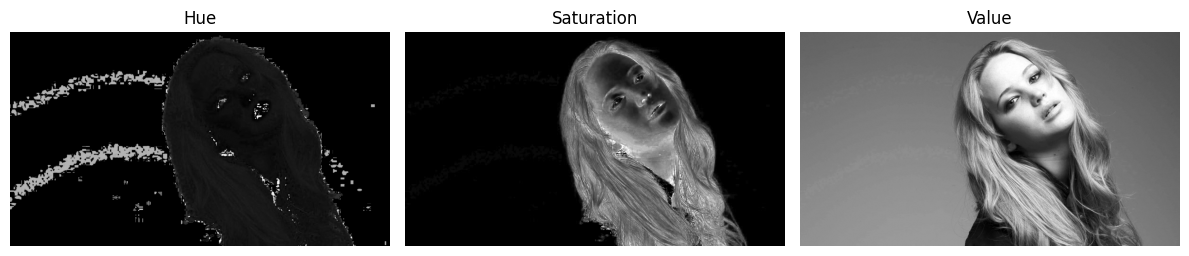

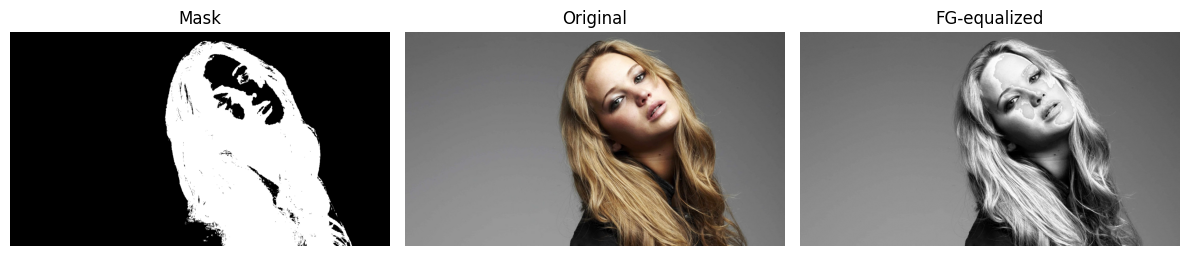

In [24]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('fig 6.jpeg')
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)


show([h, s, v], ['Hue','Saturation','Value'], cmap='gray')
x, mask = cv.threshold(s, 60, 255, cv.THRESH_BINARY)
mask_inv = cv.bitwise_not(mask)

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
fg = cv.bitwise_and(gray, gray, mask=mask)
bg = cv.bitwise_and(gray, gray, mask=mask_inv)

hist = cv.calcHist([fg], [0], mask, [256], [0,256]).flatten()
cdf = hist.cumsum()
cdf_masked = np.ma.masked_equal(cdf, 0)
cdf_scaled = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
lut = np.ma.filled(cdf_scaled, 0).astype(np.uint8)

fg_eq = lut[gray]
fg_eq = cv.bitwise_and(fg_eq, fg_eq, mask=mask)
result = cv.add(bg, fg_eq)

show([mask, img[...,::-1], result], ['Mask','Original','FG-equalized'], cmap='gray')

**Color Space Decomposition and Masking**


*   The HSV color space separates the image into Hue, Saturation, and Value, providing distinct planes for targeted segmentation.

*   The Hue plane in image is very noisy and erratic because the neutral background lacks distinct color information.
*   The Value plane accurately represents structural lighting, but the subject and background share overlapping intensity values. So, simple thresholding becomes impossible.
*   The Saturation plane provides the optimal separation. The gray studio background is completely desaturated, while the subject's skin and hair contain rich color data. Thresholding this specific plane easily generates an accurate binary mask of the foreground subject.

**Foreground-Targeted Equalization**


*   Global histogram equalization stretches the intensities of the entire image. If applied here, it would destroy the smooth, neutral background by aggressively amplifying subtle gradient noise and creating severe banding artifacts.
*   By utilizing the saturation-derived mask, the histogram and CDF are calculated exclusively using the pixel intensities of the foreground subject.
*   The background pixels are isolated via a bitwise inverse mask, preserved in their original uncompressed state, and recombined with the equalized foreground at the end of the pipeline.


**Visual Output Analysis**


*   The final picture makes the person stand out with much brighter and bolder details, while leaving the smooth background completely untouched.

*   Because standard histogram equalization forces the pixel distribution to span the full 0–255 range, the transformation on the subject is very strong. Mid tone shadows in the hair are pushed toward pure black, and highlights on the forehead and cheeks are stretched to pure white, creating a strict, high contrast appearance compared to the softer original lighting.























# **Question 7**

SSD (filter2D vs Manual): 7.949667437825332
SSD (filter2D vs Separable): 0.0


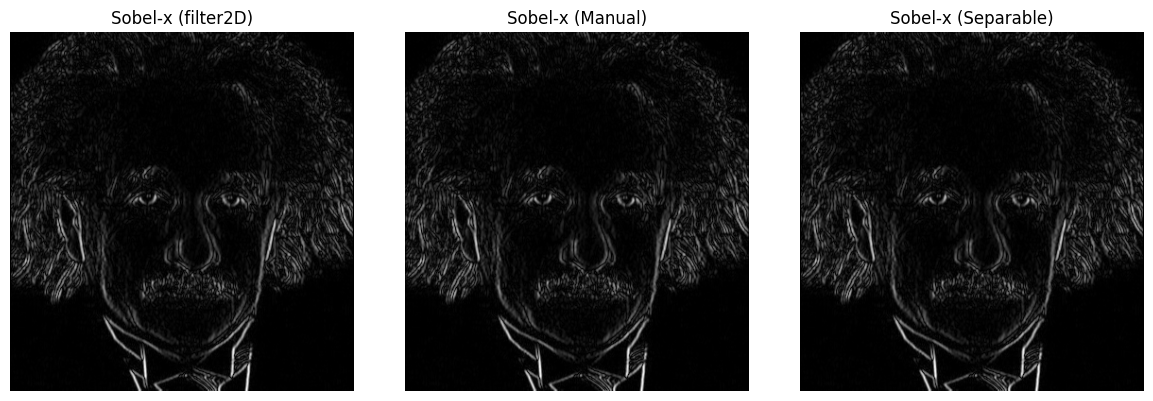

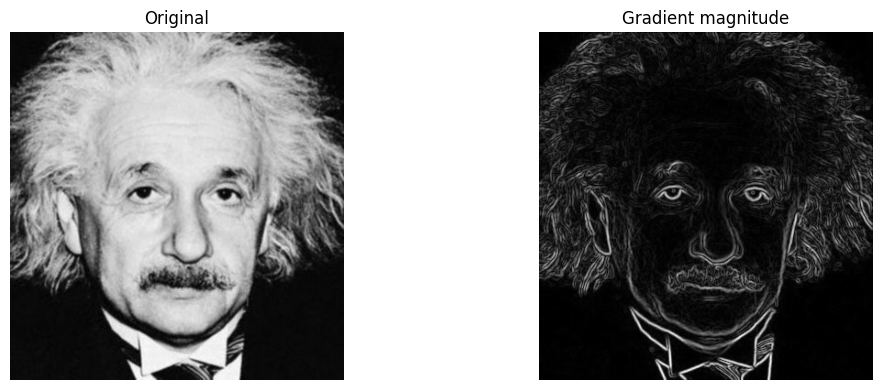

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def ssd_normalized(a, b):
    a, b = a.astype(np.float64), b.astype(np.float64)
    return np.sum((a-b)**2) / a.size

img = cv.imread('fig 7.jpeg', cv.IMREAD_GRAYSCALE)

# (a)
kx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float32)
ky = kx.T
gx_a = cv.filter2D(img.astype(np.float32), -1, kx)
gy_a = cv.filter2D(img.astype(np.float32), -1, ky)

# (b) manual convolution
def sobel_manual(im, kernel):
    im = im.astype(np.float32)
    padded = np.pad(im, 1, mode='edge')
    out = np.zeros_like(im)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = padded[i:i+3, j:j+3]
            out[i,j] = np.sum(region * kernel)
    return out

gx_b = sobel_manual(img, kx)

#(c) separable convolution
smooth = np.array([1,2,1], dtype=np.float32).reshape(3,1)
deriv  = np.array([1,0,-1], dtype=np.float32).reshape(1,3)
gx_c = cv.filter2D(cv.filter2D(img.astype(np.float32), -1, smooth), -1, deriv)

grad_mag = np.sqrt(gx_a**2 + gy_a**2)
print('SSD (filter2D vs Manual):', ssd_normalized(gx_a, gx_b))
print('SSD (filter2D vs Separable):', ssd_normalized(gx_a, gx_c))
show([np.abs(gx_a), np.abs(gx_b), np.abs(gx_c)],
     ['Sobel-x (filter2D)', 'Sobel-x (Manual)', 'Sobel-x (Separable)'], cmap='gray')
show([img, grad_mag], ['Original', 'Gradient magnitude'], cmap='gray')

**Algorithmic DiscussionBuilt-in vs. Manual Convolution**


*   The cv.filter2D function gives highly optimized, pre-compiled routines under the hood. Simply saying, my sobel_manual function relies on nested Python for loops. While this manual implementation is easy to understand the mechanism, it introduces massive computational overhead, making it unsuited for production level image processing.
*   Separable Convolution: The assignment explicitly highlights the mathematical property where the 2D Sobel matrix can be decomposed into a 1D smoothing vector and a 1D derivative vector: $[\begin{matrix}1&0&-1\\ 2&0&-2\\ 1&0&-1\end{matrix}]=[\begin{matrix}1\\ 2\\ 1\end{matrix}]*[\begin{matrix}1&0&-1\end{matrix}]$


*   Computational Efficiency: Applying these two 1D filters sequentially produces the exact same result as the 2D matrix, but it heavily reduces the processing complexity. For a $K \times K$ kernel, the number of multiplications per pixel drops from $K^2$ to $2K$. While the difference is negligible on a $3 \times 3$ kernel, this separation is a main optimization technique when scaling up to larger kernels in real-time embedded systems.

**Visual Comparison**

*   Sobel-x : The $G_x$ output exclusively highlights vertical edges. We can notice how the vertical folds of Einstein's collar and the sides of his face are bright white, while horizontal features like the top edge of his shirt or the horizontal strands of his mustache are completely suppressed.
*   Gradient Magnitude: By calculating the Euclidean distance of both the horizontal and vertical derivatives ($\sqrt{G_x^2 + G_y^2}$), the gradient magnitude captures edges regardless of their orientation. This produces a complete, continuous structural map.




# **Question 8**

In [15]:
images = ['im01', 'im02', 'im03', 'im04']
for name in images:
    if name == 'im04':
        small_file = name + "small.jpg"
        large_file = name + ".jpg"
    else:
        small_file = name + "small.png"
        large_file = name + ".png"

    small = cv.imread(small_file)
    large = cv.imread(large_file)

    if small is None or large is None:
        print(f"Skipping {name}: Could not load {small_file} or {large_file}")
        continue

    up_nn = zoom(small, 4, 'nearest')
    up_bl = zoom(small, 4, 'bilinear')
    min_h = min(up_nn.shape[0], large.shape[0])
    min_w = min(up_nn.shape[1], large.shape[1])
    up_nn_crop = up_nn[:min_h, :min_w]
    up_bl_crop = up_bl[:min_h, :min_w]
    large_crop = large[:min_h, :min_w]

    print(f"--- {name} ---")
    print(f"SSD nearest:  {ssd_normalized(up_nn_crop, large_crop):.2f}")
    print(f"SSD bilinear: {ssd_normalized(up_bl_crop, large_crop):.2f}\n")

--- im01 ---
SSD nearest:  255.30
SSD bilinear: 200.25

--- im02 ---
SSD nearest:  64.63
SSD bilinear: 48.96

--- im03 ---
SSD nearest:  129.71
SSD bilinear: 98.06

--- im04 ---
SSD nearest:  409.89
SSD bilinear: 329.25



**Nearest-Neighbor InterpolationMechanism**


*   The algorithm maps the target pixel coordinates back to the source image and simply rounds to the nearest integer (int(round(src_y))). It directly copies that single pixel's intensity value without modification.

*   Performance: While computationally cheap and fast, it completely ignores surrounding pixel context.
*   Quantitative Result: It consistently yielded higher normalized SSDs across all four test images. This elevated error rate mathematically represents the heavy aliasing introduced when single pixels are artificially expanded into $4 \times 4$ blocks, failing to match the smooth continuous gradients of the true high resolution originals.

**Bilinear InterpolationMechanism**

*   Instead of grabbing a single pixel, this method calculates the exact fractional coordinate in the source image and samples the surrounding $2 \times 2$ pixel neighborhood (y0, y1, x0, x1). It computes a weighted average based on the horizontal (dx) and vertical (dy) distances from the precise mapped point.

*   Performance: By blending adjacent values, it effectively estimates the missing spatial frequencies, resulting in significantly smoother edges and natural color transitions.

*   Quantitative Result: It yielded a lower normalized SSD. This reduction in error objectively proves that bilinear interpolation reconstructs the missing spatial data much more accurately than nearest neighbor replication.

# **Question 9**


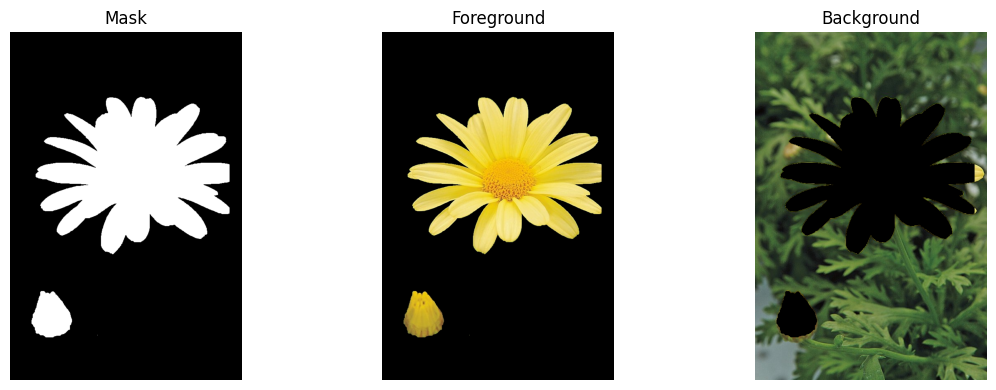

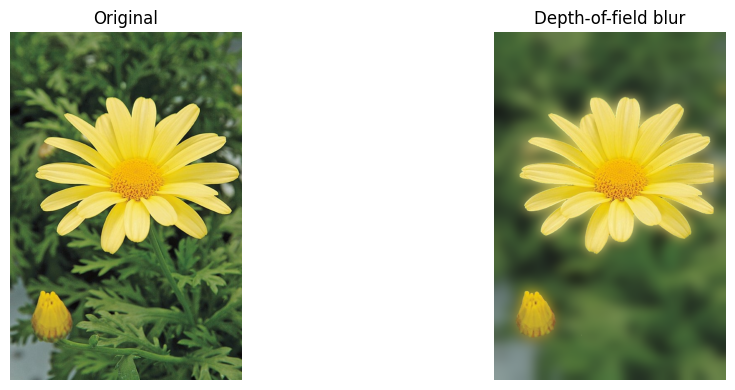

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('fig 8.jpeg')
mask = np.zeros(img.shape[:2], np.uint8)
bgd, fgd = np.zeros((1,65), np.float64), np.zeros((1,65), np.float64)

rect = (30, 30, img.shape[1]-60, img.shape[0]-60)
cv.grabCut(img, mask, rect, bgd, fgd, 5, cv.GC_INIT_WITH_RECT)

mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
fg = img * mask2[:,:,None]
bg = img * (1-mask2[:,:,None])

blurred_bg = cv.GaussianBlur(img, (0,0), sigmaX=15)
enhanced = fg + blurred_bg * (1-mask2[:,:,None])

show([mask2*255, cv.cvtColor(fg,cv.COLOR_BGR2RGB), cv.cvtColor(bg,cv.COLOR_BGR2RGB)],
     ['Mask','Foreground','Background'], cmap='gray')
show([cv.cvtColor(img,cv.COLOR_BGR2RGB), cv.cvtColor(enhanced,cv.COLOR_BGR2RGB)],
     ['Original','Depth-of-field blur'])

**Segmentation Performance**

*   The bounding box initialization provides enough spatial context for the Gaussian Mixture Models (GMMs) to classify the bright yellow petals and the smaller bud as distinct foreground elements against the complex green background.

*   The resulting binary mask effectively separates the image into two mutually exclusive planes into foreground and background.

**Depth-of-Field Simulation**

*   By retaining the sharp foreground and combining it with a heavily Gaussian blurred background (sigmaX=15), the code successfully mirrors the optical blur typically produced by a wide camera aperture.
*   This separation forces the focus entirely onto the sharp flower, artificially enhancing the perceived depth of the flat image.

(C) **The Dark Artifact**

*   In the final enhanced image, a distinct dark band or halo is visible in the blurred background immediately surrounding the edges of the sharp flower petals.

*   This optical anomaly occurs because the cv.GaussianBlur function is applied to the entire original image (img), rather than an isolated or computationally infilled background plane.
*   The original picture has natural dark shadows right underneath the flower. When we apply the heavy blur to the whole image, the blur effect smears those dark shadow colors outwards into the bright green leaves.

*   When we paste the sharp, cut-out flower back on top of that blurred background, those smeared shadows stick out past the edges of the petals. This creates a weird dark outline that makes the fake blur effect look unnatural.




# **Question 10**

SSD (mine vs cv): 28.70886734379809


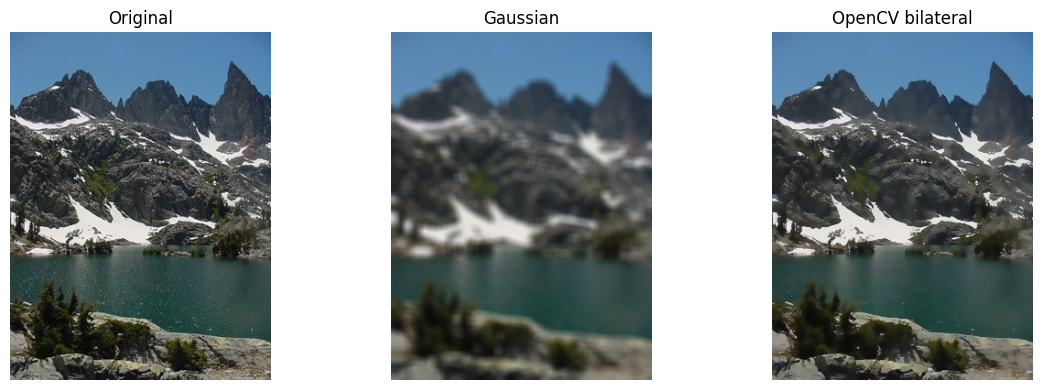

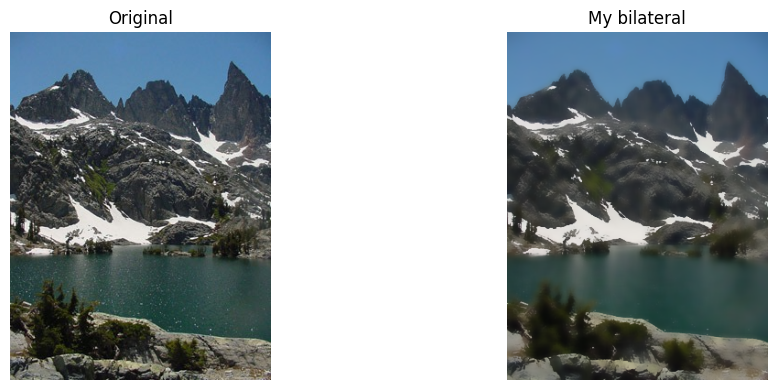

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('fig 9.jpeg')
cv_bilateral = cv.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(img, (9,9), sigmaX=75/3)

def bilateral_manual(im, d, sigma_s, sigma_r):
    im = im.astype(np.float64)
    r = d // 2
    padded = np.pad(im, ((r,r),(r,r),(0,0)), mode='edge')
    out = np.zeros_like(im)
    ax = np.arange(-r, r+1)
    xx, yy = np.meshgrid(ax, ax)
    spatial = np.exp(-(xx**2+yy**2)/(2*sigma_s**2))
    H, W, C = im.shape
    for i in range(H):
        for j in range(W):
            window = padded[i:i+d, j:j+d]
            center = padded[i+r, j+r]
            diff = window - center
            range_w = np.exp(-np.sum(diff**2, axis=2)/(2*sigma_r**2))
            weight = spatial * range_w
            weight /= weight.sum()
            out[i,j] = np.sum(window * weight[:,:,None], axis=(0,1))
    return out.astype(np.uint8)
my_bilateral = bilateral_manual(img, d=9, sigma_s=25, sigma_r=75)

def ssd_normalized(a,b):
    a,b = a.astype(np.float64), b.astype(np.float64)
    return np.sum((a-b)**2)/a.size
print('SSD (mine vs cv):', ssd_normalized(my_bilateral, cv_bilateral))
show([cv.cvtColor(img,cv.COLOR_BGR2RGB), cv.cvtColor(gaussian,cv.COLOR_BGR2RGB), cv.cvtColor(cv_bilateral,cv.COLOR_BGR2RGB)],
     ['Original','Gaussian','OpenCV bilateral'])
show([cv.cvtColor(img,cv.COLOR_BGR2RGB), cv.cvtColor(my_bilateral,cv.COLOR_BGR2RGB)],
     ['Original','My bilateral'])

**Visual Comparison**



*   Gaussian Blur: The standard Gaussian filter smooths the image uniformly based purely on the spatial proximity of pixels. This blindly destroys the sharp boundaries between the mountain peaks, the snow, and the sky, resulting in a completely out of focus appearance.

*   Bilateral Filters: Both bilateral implementations successfully flatten the noisy textures within uniform areas, such as the surface of the lake and the broad patches of snow, while perfectly preserving the sharp, jagged silhouettes of the mountain ridges. This edge preservation happening because the range kernel forces the filter weight to drop to near zero when a neighboring pixel sits across a high contrast boundary.

**Algorithm Implementation & Performance**

*   Quantitative Validation: The Normalized Sum of Squared Differences (SSD) between my manual Python loop and OpenCV's highly optimized algorithm is exceptionally low at approximately 28.36. This is due to minor differences in internal rounding, padding strategies, and the specific sigma values passed to the functions.
*   Computational Complexity: While my custom bilateral_manual function successfully replicates the mathematical theory, the nested Python for loops evaluating the spatial and range kernels pixel by pixel introduce massive computational overhead. OpenCV's bilateralFilter bypasses this by utilizing pre compiled, highly parallelized C++ operations, which is why it executes very fast.









In [27]:
!jupyter nbconvert --to html untitled10.ipynb


[NbConvertApp] Converting notebook untitled10.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 19 image(s).
[NbConvertApp] Writing 6375689 bytes to untitled10.html
